  
<center> <h1><b>MÓDULO: REDES NEURONALES Y DEEP LEARNING</h1></b></center>
<h1><b>PROYECTO 1:</h1></b>
<center> <h1><b> Desarrollo de un Modelo de Red Neuronal Profunda para la Clasificación de Actividades Humanas mediante Datos de Sensores Móviles</h1></b></center>



**Integrantes:**

Ing. Karina Raquel Romero Flores

Ing. Percy Pedro Fuentes Ramos

Lic. Juan Marcos Miranda Nina

# **1 Selección y Preprocesamiento del Dataset**

**Importación de las bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import requests
import io
import os

**Importación de la base de datos**

In [2]:
# URL del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

# 1️⃣ descargar
!wget -O "UCI HAR Dataset.zip" $url

# 2️⃣ verificar tamaño
size = os.path.getsize("UCI HAR Dataset.zip") / (1024*1024)
print("Tamaño del dataset:", round(size,2), "MB")

# 3️⃣ extraer
with zipfile.ZipFile("UCI HAR Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extraído correctamente")

--2026-03-14 12:05:35--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [                 <=>]  58.17M  18.4MB/s    in 3.9s    

2026-03-14 12:05:40 (14.9 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

Tamaño del dataset: 58.17 MB
Dataset extraído correctamente


El Dataset fue obtenido del repositorio de aprendizaje automático de la Universidad de California Irvine (UCI), conocido como UCI Machine Learning Repository.
El dataset utilizado en este estudio corresponde al conjunto de datos denominado:

UCI Human Activity Recognition Using Smartphones Dataset
https://archive-beta.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

Este dataset contiene información sobre actividades humanas capturadas mediante sensores de teléfonos inteligentes, específicamente acelerómetros y giroscopios.

1 WALKING,

2 WALKING_UPSTAIRS,

3 WALKING_DOWNSTAIRS,

4 SITTING,

5 STANDING,

6 LAYING

In [3]:
#cargando los datos
# features
features = pd.read_csv(
    "UCI HAR Dataset/features.txt",
    sep="\s+",
    header=None,
    names=["index","feature"]
)

# datos entrenamiento
X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    sep="\s+",
    header=None
)

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    header=None,
    names=["activity"]
)

# datos test
X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    sep="\s+",
    header=None
)

y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    header=None,
    names=["activity"]
)

# nombres de columnas
X_train.columns = features["feature"]
X_test.columns = features["feature"]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_699/1000731800.py:5: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/tmp/ipykernel_699/1000731800.py:13: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/tmp/ipykernel_699/1000731800.py:26: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


**Creación de la Master Table (MT)**

In [4]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

data = pd.concat([train, test], axis=0)

In [5]:
data

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2


In [6]:
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5


In [7]:
data.tail()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2
2946,0.153627,-0.018437,-0.137018,-0.330046,-0.195253,-0.164339,-0.430974,-0.218295,-0.229933,-0.111527,...,-0.072237,-0.436940,0.598808,-0.287951,0.876030,-0.024965,-0.660080,0.263936,0.188103,2


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10299 entries, 0 to 2946
Columns: 562 entries, tBodyAcc-mean()-X to activity
dtypes: float64(561), int64(1)
memory usage: 44.2 MB


In [9]:
data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,-0.298592,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284,3.624624
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.320199,0.308796,0.336591,0.447364,0.616188,0.484770,0.511158,0.305468,0.268898,1.743695
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262625,-0.024902,-0.121019,-0.992360,-0.976990,-0.979137,-0.993293,-0.977017,-0.979064,-0.935788,...,-0.536174,-0.841847,-0.124694,-0.287031,-0.493108,-0.389041,-0.817288,0.002151,-0.131880,2.000000
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,-0.335160,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882,4.000000
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087405,-0.288149,-0.014641,...,-0.113167,-0.487981,0.149005,0.291490,0.536137,0.365996,-0.521503,0.250790,0.102970,5.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


**Análisis exploratorio (EDA)**

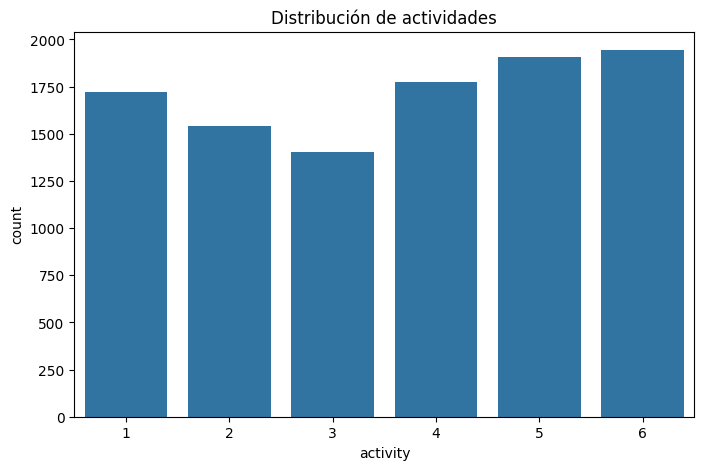

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x="activity", data=data)
plt.title("Distribución de actividades")
plt.show()

**Limpieza, normalización, codificación, imputación, etc.**

In [11]:
#Limpieza de datos
print("Valores nulos:", data.isnull().sum().sum())

Valores nulos: 0


In [12]:
# Separar variables
X = data.drop("activity", axis=1)
y = data["activity"] - 1

In [13]:
# Dividir train/test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Dataset sin PCA
X_train_sin_pca = X_train_scaled
X_test_sin_pca = X_test_scaled

In [22]:
print(X_train_sin_pca.shape)
print(X_test_sin_pca.shape)

(8239, 561)
(2060, 561)


In [16]:
# Dataset con PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_con_pca = pca.fit_transform(X_train_scaled)
X_test_con_pca = pca.transform(X_test_scaled)

print("Varianza explicada:", sum(pca.explained_variance_ratio_))

Varianza explicada: 0.871587904754406


In [23]:
print(X_train_con_pca.shape)
print(X_test_con_pca.shape)

(8239, 50)
(2060, 50)


De los 50 componentes principales se conserva aproximadamente el 87% de la información original del dataset

# **2 Aplicación de Redes Neuronales**

**Construcción de la Red Neuronal Profunda (DNN)**

In [ ]:
# Modelo SIN PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_sin_pca = Sequential()

model_sin_pca.add(Dense(256, activation="relu", input_shape=(X_train_sin_pca.shape[1],)))
model_sin_pca.add(Dropout(0.3)) # Durante el entrenamiento se van a pagar aleatoriamente el 30% de neuronas de la capa

model_sin_pca.add(Dense(128, activation="relu"))
model_sin_pca.add(Dropout(0.3))

model_sin_pca.add(Dense(64, activation="relu"))

model_sin_pca.add(Dense(6, activation="softmax"))

model_sin_pca.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,414 (724.27 KB)

 Trainable params: 185,414 (724.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Modelo CON PCA
model_con_pca = Sequential()

model_con_pca.add(Dense(256, activation="relu", input_shape=(X_train_con_pca.shape[1],)))
model_con_pca.add(Dropout(0.3))

model_con_pca.add(Dense(128, activation="relu"))
model_con_pca.add(Dropout(0.3))

model_con_pca.add(Dense(64, activation="relu"))

model_con_pca.add(Dense(6, activation="softmax"))

model_con_pca.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,598 (213.27 KB)

 Trainable params: 54,598 (213.27 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de la estructura de la DNN**

La arquitectura de la red neuronal se diseñó para resolver un problema de clasificación multiclase de actividades humanas a partir de datos de sensores.

Se utilizaron capas densas (256, 128 y 64 neuronas) con una reducción progresiva de neuronas para permitir que el modelo aprenda representaciones cada vez más abstractas de los datos.

La función de activación ReLU se emplea en las capas ocultas porque permite aprender relaciones no lineales y mejora la eficiencia del entrenamiento.

La capa de salida utiliza Softmax con 6 neuronas, correspondiente a las 6 clases de actividades, permitiendo obtener probabilidades para cada categoría.

Se incorporó Dropout (0.3) para reducir el sobreajuste durante el entrenamiento.

Finalmente, se compararon dos modelos: uno con PCA y otro sin PCA, con el objetivo de analizar el impacto de la reducción de dimensionalidad en el rendimiento del modelo.

In [ ]:
# Compilación de ambos modelos
model_sin_pca.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_con_pca.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Entrenamiento sin PCA
hist_sin_pca = model_sin_pca.fit(
    X_train_sin_pca, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_sin_pca, y_test)
)

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8366 - loss: 0.4015 - val_accuracy: 0.9563 - val_loss: 0.1104
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9414 - loss: 0.1495 - val_accuracy: 0.9583 - val_loss: 0.1128
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9534 - loss: 0.1255 - val_accuracy: 0.9665 - val_loss: 0.0803
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9623 - loss: 0.0971 - val_accuracy: 0.9718 - val_loss: 0.0834
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9620 - loss: 0.0996 - val_accuracy: 0.9655 - val_loss: 0.0818
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9684 - loss: 0.0768 - val_accuracy: 0.9757 - val_loss: 0.0640
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9714 - loss: 0.0804 - val_accuracy: 0.9752 - val_loss: 0.0649
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9723 - loss: 0.0726 - val_accuracy: 

In [ ]:
# Entrenamiento con PCA
hist_con_pca = model_con_pca.fit(
    X_train_con_pca, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_con_pca, y_test)
)

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8161 - loss: 0.4591 - val_accuracy: 0.9325 - val_loss: 0.1773
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9152 - loss: 0.2094 - val_accuracy: 0.9393 - val_loss: 0.1510
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9301 - loss: 0.1760 - val_accuracy: 0.9451 - val_loss: 0.1389
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9377 - loss: 0.1501 - val_accuracy: 0.9422 - val_loss: 0.1337
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9448 - loss: 0.1371 - val_accuracy: 0.9456 - val_loss: 0.1322
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9510 - loss: 0.1213 - val_accuracy: 0.9529 - val_loss: 0.1261
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9536 - loss: 0.1112 - val_accuracy: 0.9515 - val_loss: 0.1326
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9530 - loss: 0.1124 - val_accuracy: 0.

**Evaluación del modelo**

In [ ]:
# Sin PCA
loss_sin_pca, acc_sin_pca = model_sin_pca.evaluate(
    X_test_sin_pca,
    y_test
)

print("Accuracy sin PCA:", acc_sin_pca)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9791 - loss: 0.0636
Accuracy sin PCA: 0.9791262149810791


In [ ]:
# Con PCA
loss_con_pca, acc_con_pca = model_con_pca.evaluate(
    X_test_con_pca,
    y_test
)

print("Accuracy con PCA:", acc_con_pca)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9592 - loss: 0.1172
Accuracy con PCA: 0.9592233300209045


In [ ]:
# Comparación de resultados
print("Resultados del modelo")
print("----------------------")
print("Accuracy sin PCA:", acc_sin_pca)
print("Accuracy con PCA:", acc_con_pca)

Resultados del modelo
----------------------
Accuracy sin PCA: 0.9791262149810791
Accuracy con PCA: 0.9592233300209045


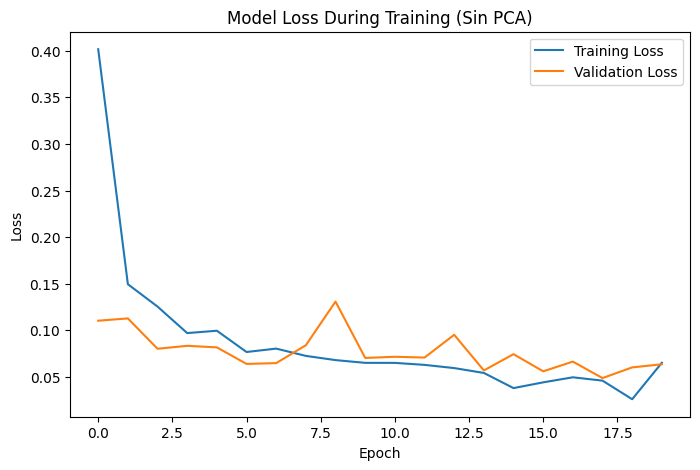

In [ ]:
# Gráfico de pérdida (loss) sin PCA
plt.figure(figsize=(8,5))

plt.plot(hist_sin_pca.history['loss'], label='Training Loss')
plt.plot(hist_sin_pca.history['val_loss'], label='Validation Loss')

plt.title('Model Loss During Training (Sin PCA)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

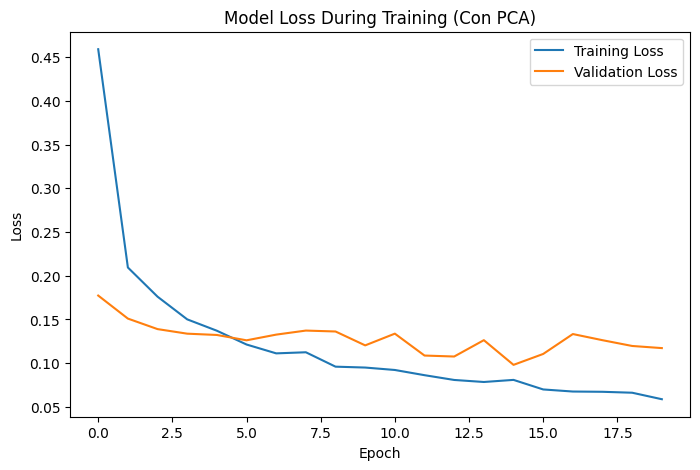

In [ ]:
# Gráfico de pérdida (loss) con PCA
plt.figure(figsize=(8,5))

plt.plot(hist_con_pca.history['loss'], label='Training Loss')
plt.plot(hist_con_pca.history['val_loss'], label='Validation Loss')

plt.title('Model Loss During Training (Con PCA)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

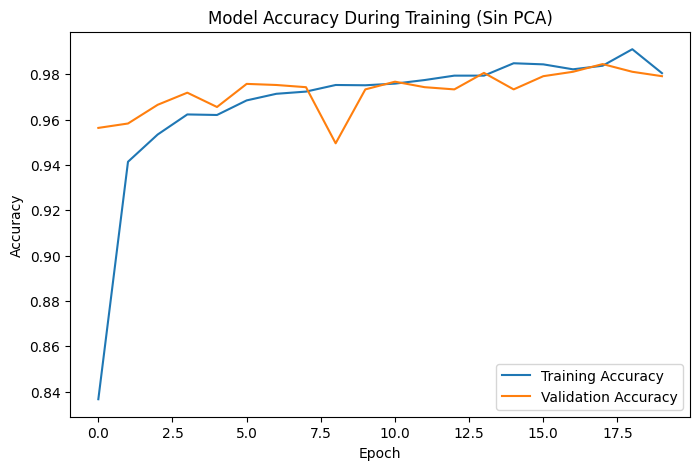

In [ ]:
# Accuracy sin PCA
plt.figure(figsize=(8,5))

plt.plot(hist_sin_pca.history['accuracy'], label='Training Accuracy')
plt.plot(hist_sin_pca.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy During Training (Sin PCA)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

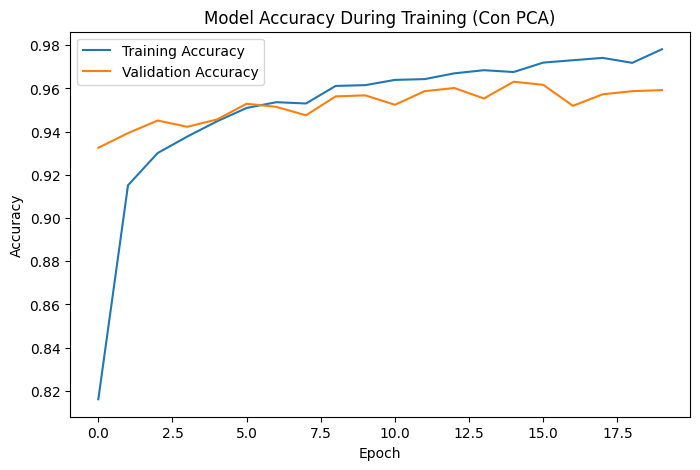

In [ ]:
# Accuracy con PCA
plt.figure(figsize=(8,5))

plt.plot(hist_con_pca.history['accuracy'], label='Training Accuracy')
plt.plot(hist_con_pca.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy During Training (Con PCA)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# **3 Métricas de Evaluación**

In [ ]:
# Predicciones modelo sin PCA
import numpy as np

y_pred_sin_pca = model_sin_pca.predict(X_test_sin_pca)
pred_sin_pca = np.argmax(y_pred_sin_pca, axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# Metricas sin PCA
from sklearn.metrics import classification_report

print("Reporte SIN PCA")
print(classification_report(y_test, pred_sin_pca))

Reporte SIN PCA
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       369
           1       0.98      1.00      0.99       270
           2       0.99      0.99      0.99       284
           3       0.96      0.95      0.95       377
           4       0.95      0.96      0.95       354
           5       1.00      1.00      1.00       406

    accuracy                           0.98      2060
   macro avg       0.98      0.98      0.98      2060
weighted avg       0.98      0.98      0.98      2060



In [ ]:
# Predicciones modelo CON PCA
y_pred_con_pca = model_con_pca.predict(X_test_con_pca)
pred_con_pca = np.argmax(y_pred_con_pca, axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
# Metricas con PCA
print("Reporte CON PCA")
print(classification_report(y_test, pred_con_pca))

Reporte CON PCA
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       369
           1       0.99      0.99      0.99       270
           2       0.99      0.98      0.98       284
           3       0.90      0.92      0.91       377
           4       0.91      0.89      0.90       354
           5       1.00      1.00      1.00       406

    accuracy                           0.96      2060
   macro avg       0.96      0.96      0.96      2060
weighted avg       0.96      0.96      0.96      2060



**Matriz de confusión**

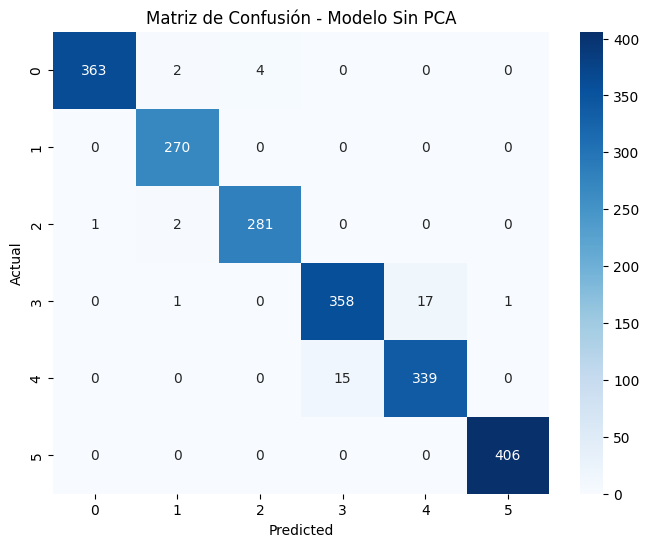

In [ ]:
# Matriz de confución sin PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_sin_pca = confusion_matrix(y_test, pred_sin_pca)

plt.figure(figsize=(8,6))
sns.heatmap(cm_sin_pca, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Modelo Sin PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

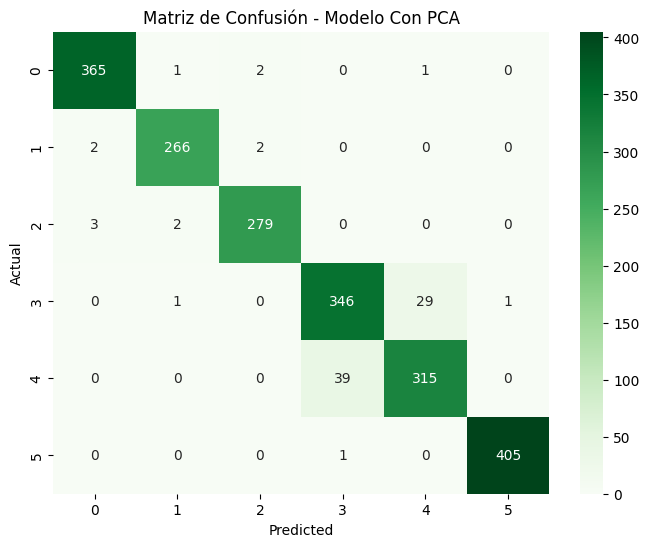

In [ ]:
# Matriz de confución con PCA
cm_con_pca = confusion_matrix(y_test, pred_con_pca)

plt.figure(figsize=(8,6))
sns.heatmap(cm_con_pca, annot=True, fmt="d", cmap="Greens")

plt.title("Matriz de Confusión - Modelo Con PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

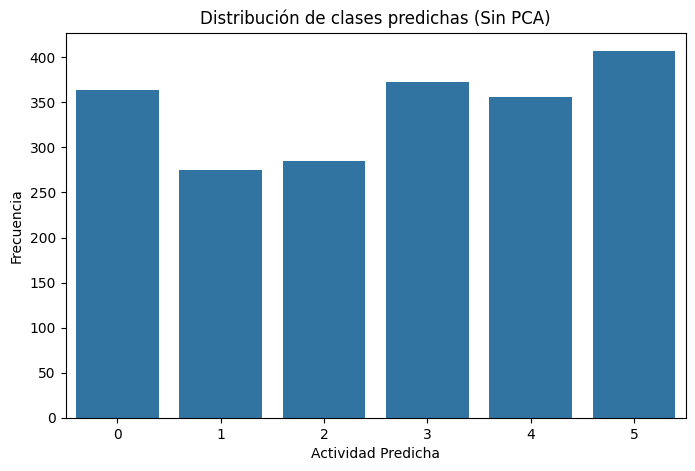

In [ ]:
# Distribución de clases predichas sin PCA
plt.figure(figsize=(8,5))
sns.countplot(x=pred_sin_pca)

plt.title("Distribución de clases predichas (Sin PCA)")
plt.xlabel("Actividad Predicha")
plt.ylabel("Frecuencia")

plt.show()

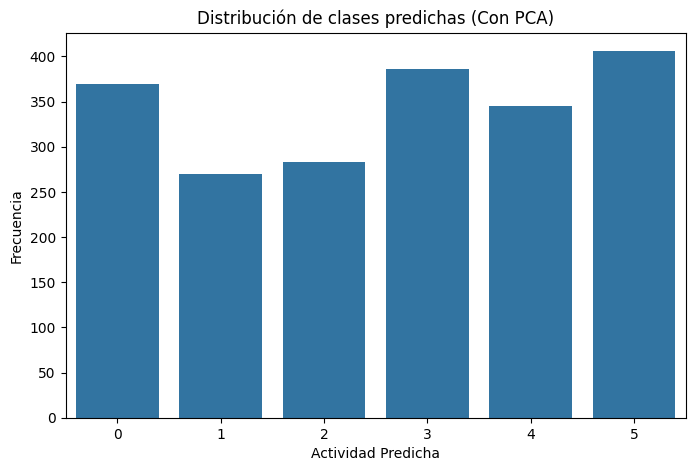

In [ ]:
# Distribución de clases predichas con PCA

plt.figure(figsize=(8,5))
sns.countplot(x=pred_con_pca)

plt.title("Distribución de clases predichas (Con PCA)")
plt.xlabel("Actividad Predicha")
plt.ylabel("Frecuencia")

plt.show()

**Gráfico de comparación de accuracy**

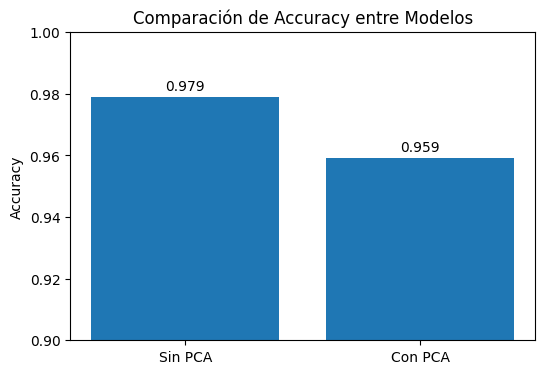

In [ ]:
import matplotlib.pyplot as plt

models = ['Sin PCA', 'Con PCA']
accuracies = [acc_sin_pca, acc_con_pca]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title('Comparación de Accuracy entre Modelos')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

# **4. Análisis de Resultados**

Se entrenaron dos modelos de redes neuronales profundas para la clasificación de actividades humanas utilizando el dataset UCI HAR. El primer modelo utilizó las variables originales normalizadas, mientras que el segundo aplicó reducción de dimensionalidad mediante PCA a 50 componentes principales.

Los resultados muestran que el modelo sin PCA alcanzó una precisión aproximada del 97.9%, mientras que el modelo con PCA obtuvo una precisión cercana al 95.9%. Esto indica que la reducción de dimensionalidad reduce ligeramente el desempeño del modelo, aunque mantiene un nivel de precisión alto.

**Interpretación**

El modelo sin PCA logra un mejor rendimiento debido a que utiliza todas las variables originales del dataset, lo que permite capturar mayor cantidad de información sobre las señales de acelerómetros y giroscopios registradas por los smartphones.

En cambio, el uso de PCA reduce la dimensionalidad del conjunto de datos, lo que simplifica el modelo y disminuye el tiempo de entrenamiento, pero también puede eliminar parte de la información relevante para la clasificación de las actividades.

**Visualizaciones**

Se analizaron las curvas de pérdida (loss) y precisión (accuracy) durante el entrenamiento para evaluar la convergencia del modelo. Asimismo, se utilizaron matrices de confusión para identificar qué actividades eran clasificadas correctamente y cuáles presentaban mayores confusiones.

Además, se compararon gráficamente los resultados obtenidos por los modelos con y sin PCA para observar las diferencias en desempeño.

**Impacto potencial en negocio o aplicación real**

Los modelos de reconocimiento de actividades humanas tienen múltiples aplicaciones en diferentes áreas. En el ámbito de la salud, pueden utilizarse para monitorear la actividad física de pacientes o detectar patrones de sedentarismo. En aplicaciones deportivas, permiten analizar el desempeño y el nivel de actividad de los usuarios.

Asimismo, en dispositivos móviles y wearables, estos modelos pueden integrarse para reconocer automáticamente las actividades del usuario, lo que facilita el desarrollo de aplicaciones de seguimiento de actividad física, rehabilitación o asistencia para personas mayores.

# **5. Conclusiones y Recomendaciones**

**Hallazgos más relevantes**

El dataset utilizado contiene 561 características provenientes de sensores móviles, lo que permite capturar información detallada de las actividades humanas.

La aplicación de PCA redujo la dimensionalidad a 50 variables, manteniendo la información relevante del conjunto de datos.

El modelo de Red Neuronal Profunda alcanzó niveles de precisión superiores al 97%, demostrando una alta capacidad para clasificar actividades humanas.

**Aplicabilidad de los modelos**

El modelo puede utilizarse en aplicaciones de monitoreo de actividad física, salud digital y dispositivos wearables.

También puede integrarse en sistemas inteligentes basados en sensores móviles para reconocer actividades humanas automáticamente.

**Líneas futuras de trabajo**

Evaluar otros modelos de deep learning como CNN o LSTM para mejorar la detección de patrones temporales.

Probar diferentes configuraciones de arquitectura e hiperparámetros para optimizar el rendimiento.

Implementar el modelo en aplicaciones móviles o sistemas en tiempo real.